In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [88]:
df=pd.read_csv("../data/raw/tesla_stocks.csv")

In [89]:
df.head()


,Date,Close/Last,Volume,Open,High,Low
0,12/06/2024,$389.22,81455830,$377.42,$389.49,$370.80
1,12/05/2024,$369.49,81403570,$359.87,$375.43,$359.50
2,12/04/2024,$357.93,50810870,$353.00,$358.10,$348.60
3,12/03/2024,$351.42,58267200,$351.80,$355.69,$348.20
4,12/02/2024,$357.09,77986480,$352.38,$360.00,$351.1501


In [90]:
df.tail()

,Date,Close/Last,Volume,Open,High,Low
2512,12/12/2014,$13.80,107507556,$13.6547,$14.112,$13.6333
2513,12/11/2014,$13.9253,100266835,$14.0353,$14.362,$13.882
2514,12/10/2014,$13.9893,109622540,$14.2753,$14.4513,$13.8467
2515,12/09/2014,$14.4593,141405904,$13.956,$14.5153,$13.618
2516,12/08/2014,$14.2907,138260571,$14.7693,$14.9907,$14.156


In [104]:
df['Date'] = pd.to_datetime(df['Date'])

In [105]:
df = df.sort_values(by='Date')

In [106]:
df.reset_index(inplace=True, drop=True)

In [107]:
df.head()

,Date,Volume,Open,High,Low,Close
0,2014-12-08,138260571,14.7693,14.9907,14.1560,14.2907
1,2014-12-09,141405904,13.9560,14.5153,13.6180,14.4593
2,2014-12-10,109622540,14.2753,14.4513,13.8467,13.9893
3,2014-12-11,100266835,14.0353,14.3620,13.8820,13.9253
4,2014-12-12,107507556,13.6547,14.1120,13.6333,13.8000


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2517 non-null   datetime64[us]
 1   Volume  2517 non-null   int64         
 2   Open    2517 non-null   float64       
 3   High    2517 non-null   float64       
 4   Low     2517 non-null   float64       
 5   Close   2517 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 118.1 KB


In [109]:
df.isnull().sum()

Date      0
Volume    0
Open      0
High      0
Low       0
Close     0
dtype: int64

In [110]:
df.duplicated().sum()

np.int64(0)

In [111]:
df['Open'] = df['Open'].str.replace('$', '', regex=False).astype(float)
df['High'] = df['High'].str.replace('$', '', regex=False).astype(float)
df['Low'] = df['Low'].str.replace('$', '', regex=False).astype(float)
df['Close'] = df['Close/Last'].str.replace('$', '', regex=False).astype(float)

AttributeError: Can only use .str accessor with string values, not floating

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2517 non-null   datetime64[us]
 1   Volume  2517 non-null   int64         
 2   Open    2517 non-null   float64       
 3   High    2517 non-null   float64       
 4   Low     2517 non-null   float64       
 5   Close   2517 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 118.1 KB


In [113]:
df.drop(columns=['Close/Last'], inplace=True)   

KeyError: "['Close/Last'] not found in axis"

In [114]:
df.describe()

,Date,Volume,Open,High,Low,Close
count,2517,2.517000e+03,2517.000000,2517.000000,2517.000000,2517.000000
mean,2019-12-07 20:10:00.715137,1.121374e+08,112.999237,115.523752,110.372709,112.985214
min,2014-12-08 00:00:00,1.065415e+07,9.488000,10.331300,9.403300,9.578000
25%,2017-06-08 00:00:00,6.657777e+07,17.026000,17.300000,16.719300,17.016700
50%,2019-12-06 00:00:00,9.283534e+07,25.111300,25.574000,24.673300,25.176000
75%,2022-06-07 00:00:00,1.294696e+08,219.400000,222.990000,213.740000,218.890000
max,2024-12-06 00:00:00,9.140809e+08,411.470000,414.496600,405.666600,409.970000
std,NaN,7.410916e+07,111.712843,114.261293,109.016181,111.647804


In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2517 non-null   datetime64[us]
 1   Volume  2517 non-null   int64         
 2   Open    2517 non-null   float64       
 3   High    2517 non-null   float64       
 4   Low     2517 non-null   float64       
 5   Close   2517 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 118.1 KB


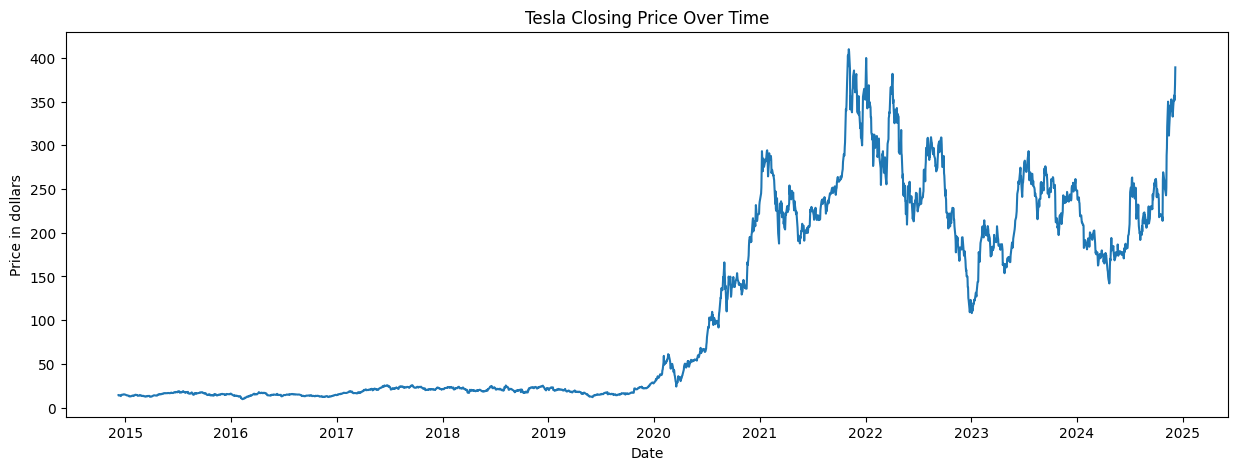

In [116]:
plt.figure(figsize=(15,5))

plt.plot(df['Date'], df['Close'])

plt.xlabel('Date')
plt.ylabel('Price in dollars')
plt.title('Tesla Closing Price Over Time')

plt.show()

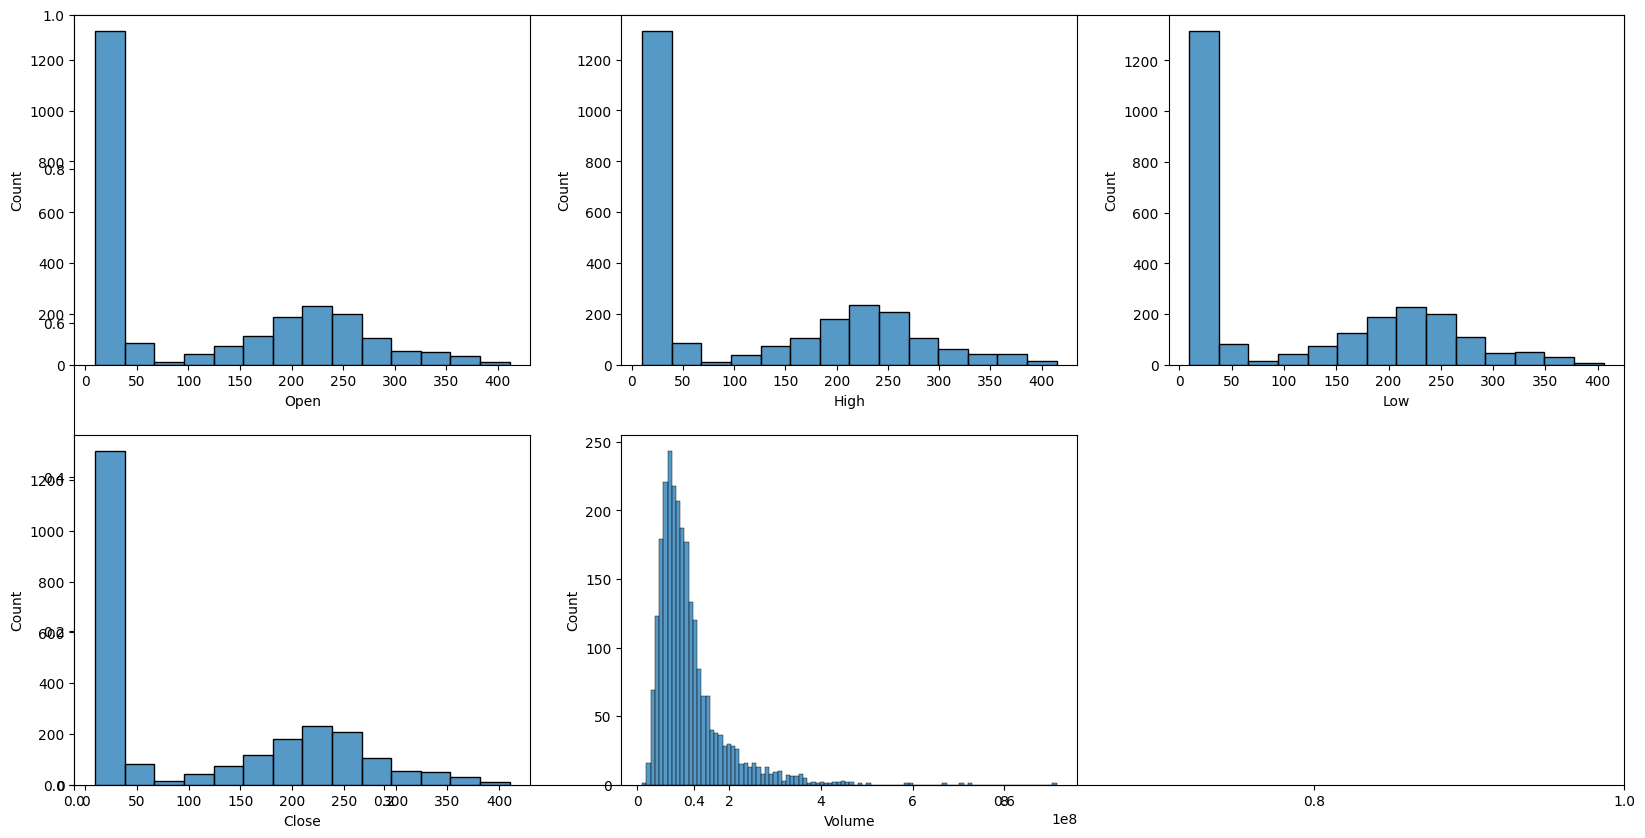

In [118]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.histplot(df[col])
plt.show()

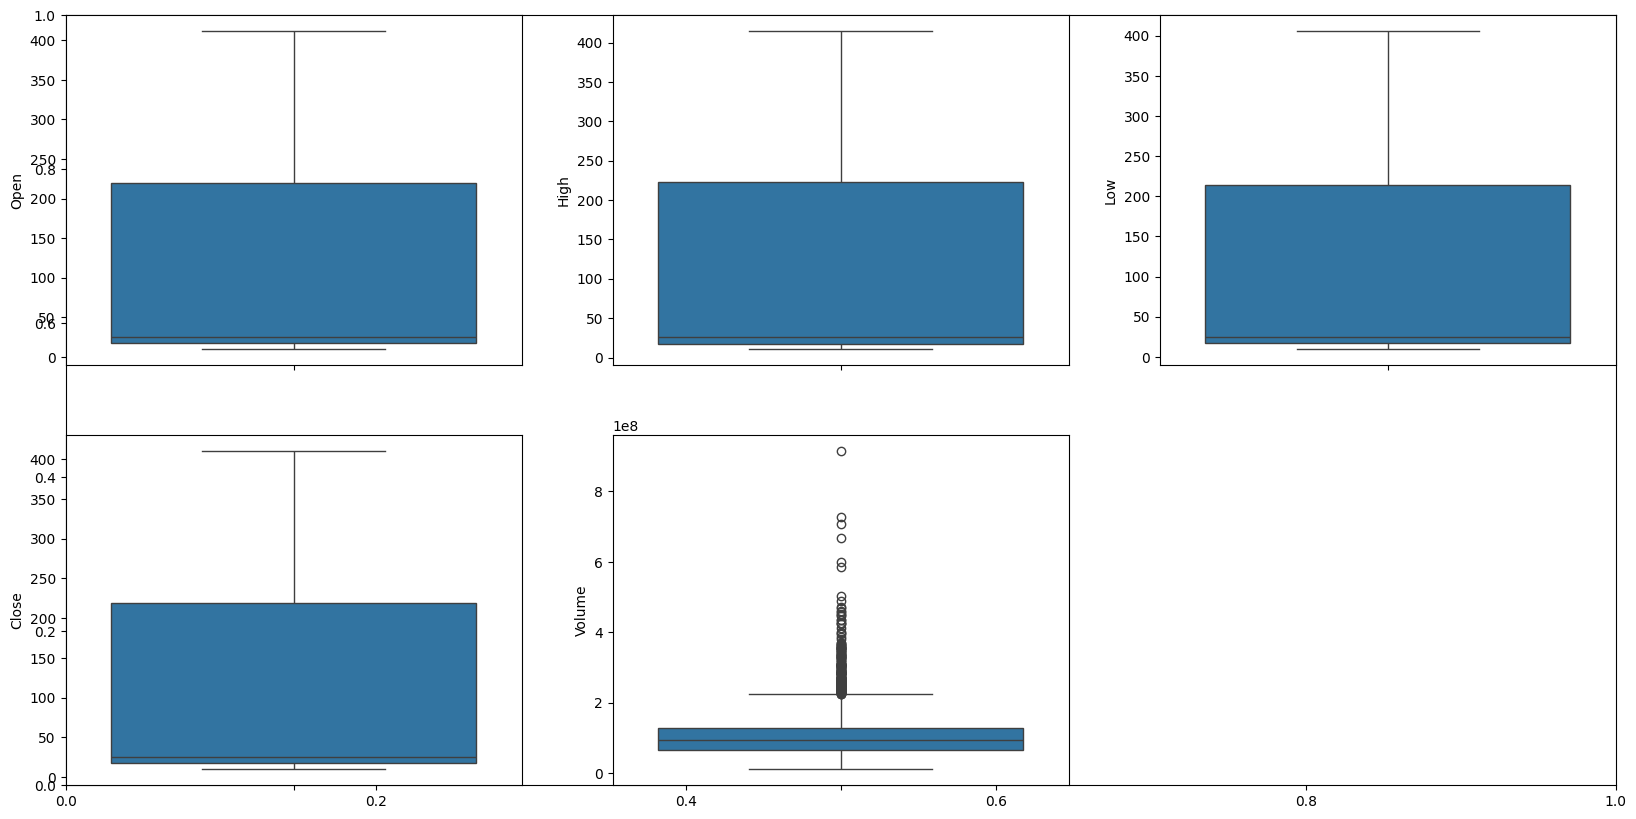

In [119]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

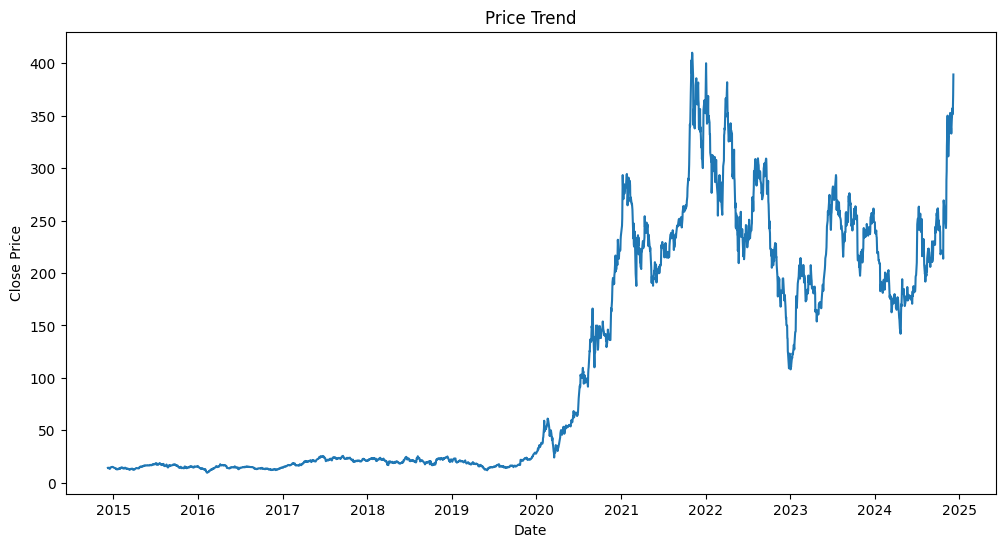

In [120]:
#price trend graph
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Price Trend')    
plt.show()

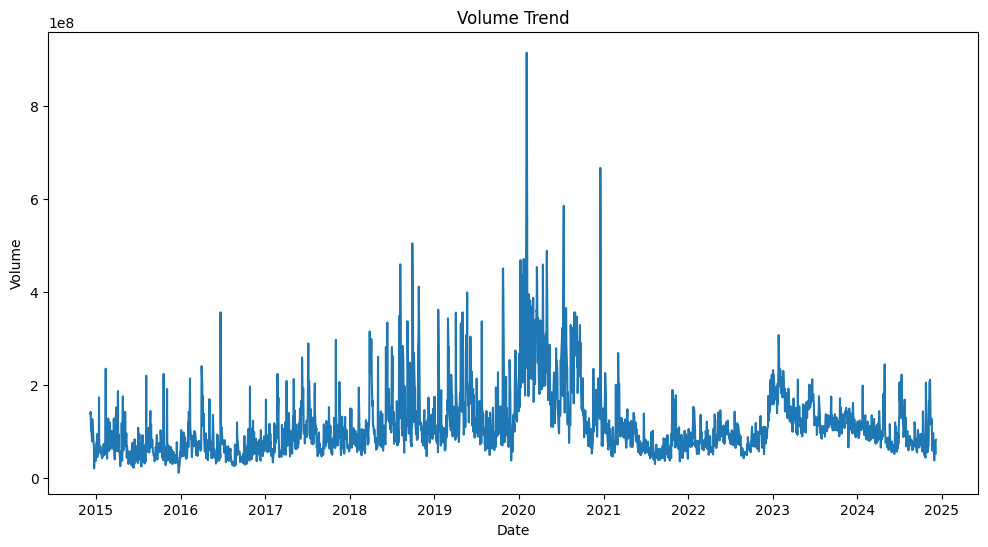

In [121]:
#volume visualization
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Volume Trend')
plt.show()

In [125]:
df['Intraday_change'] = df['Close'] - df['Open']
df.head()

,Date,Volume,Open,High,Low,Close,Open vs close,Intraday_change
0,2014-12-08,138260571,14.7693,14.9907,14.1560,14.2907,-0.4786,-0.4786
1,2014-12-09,141405904,13.9560,14.5153,13.6180,14.4593,0.5033,0.5033
2,2014-12-10,109622540,14.2753,14.4513,13.8467,13.9893,-0.2860,-0.2860
3,2014-12-11,100266835,14.0353,14.3620,13.8820,13.9253,-0.1100,-0.1100
4,2014-12-12,107507556,13.6547,14.1120,13.6333,13.8000,0.1453,0.1453


In [126]:
print(df['Intraday_change'].mean())

-0.014022765196662994


Feature Engineering


In [135]:
df['Daily_Return'] = df['Close'].pct_change()

In [136]:
df['MA_7'] = df['Close'].rolling(window=7).mean()

df['MA_30'] = df['Close'].rolling(window=30).mean()

In [137]:
df['Volatility_7'] = df['Daily_Return'].rolling(window=7).std()

In [127]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

In [129]:
import numpy as np
df['is_quarter_end'] = np.where(df['month']%3==0, 1, 0)
df.head()

,Date,Volume,Open,High,Low,Close,Open vs close,Intraday_change,day,month,year,is_quarter_end
0,2014-12-08,138260571,14.7693,14.9907,14.1560,14.2907,-0.4786,-0.4786,8,12,2014,1
1,2014-12-09,141405904,13.9560,14.5153,13.6180,14.4593,0.5033,0.5033,9,12,2014,1
2,2014-12-10,109622540,14.2753,14.4513,13.8467,13.9893,-0.2860,-0.2860,10,12,2014,1
3,2014-12-11,100266835,14.0353,14.3620,13.8820,13.9253,-0.1100,-0.1100,11,12,2014,1
4,2014-12-12,107507556,13.6547,14.1120,13.6333,13.8000,0.1453,0.1453,12,12,2014,1


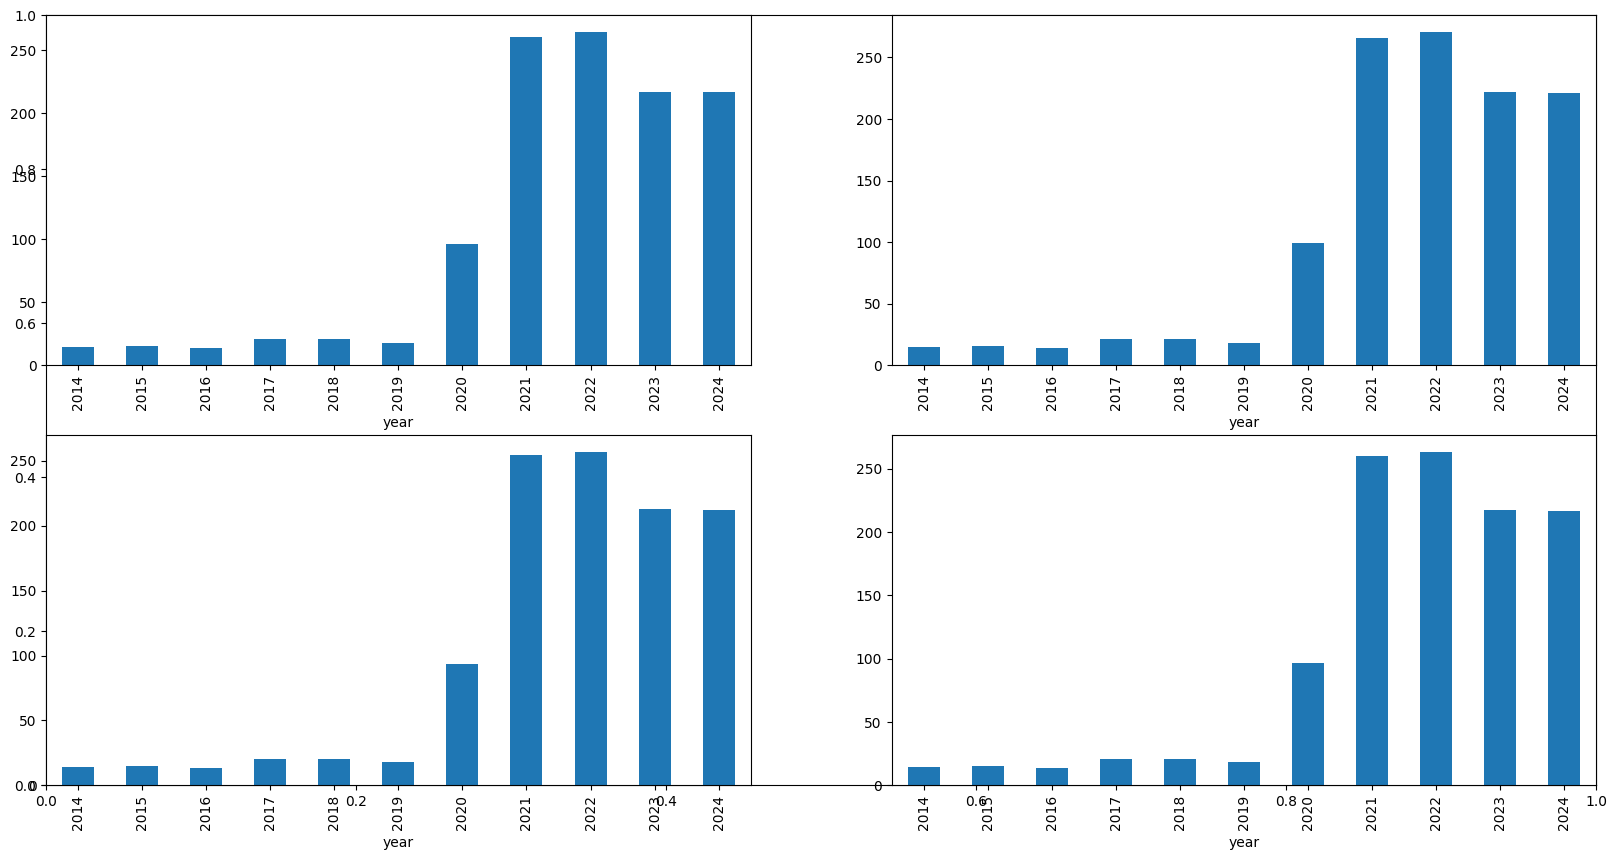

In [130]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

# This code is modified by Susobhan Akhuli

In [131]:
df.drop('Date', axis=1).groupby('is_quarter_end').mean()

,Volume,Open,High,Low,Close,Open vs close,Intraday_change,day,month,year
is_quarter_end,,,,,,,,,,
0,1.133693e+08,113.774313,116.274825,111.085269,113.716015,-0.058298,-0.058298,15.714542,6.098145,2019.509874
1,1.097041e+08,111.468323,114.040250,108.965276,111.541752,0.073429,0.073429,15.765957,7.432624,2019.278960


In [132]:
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

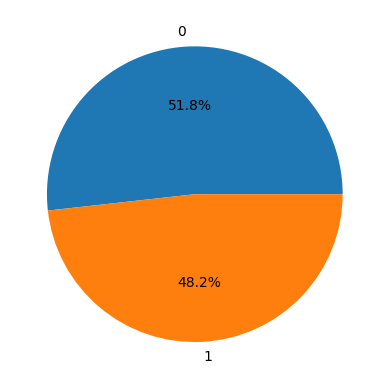

In [133]:
plt.pie(df['target'].value_counts().values, 
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

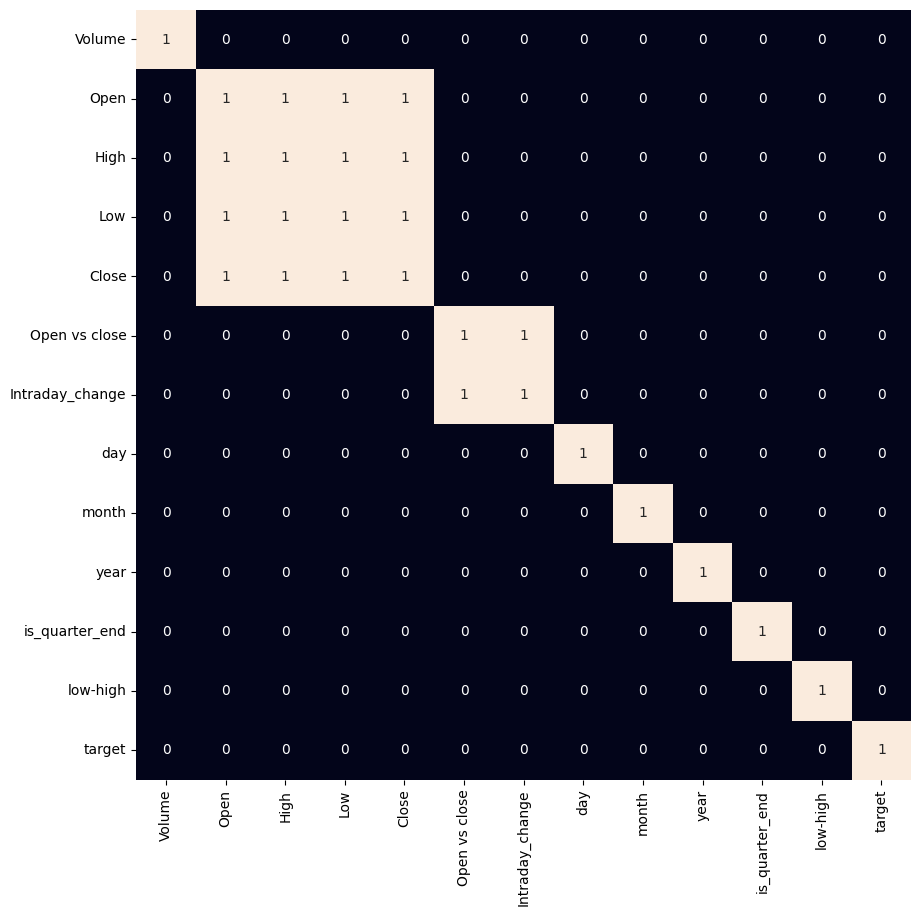

In [134]:
plt.figure(figsize=(10, 10)) 

# As our concern is with the highly 
# correlated features only so, we will visualize 
# our heatmap as per that criteria only. 
sb.heatmap(df.drop('Date', axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()

# This code is modified by Susobhan Akhuli

In [138]:
df['Close_lag1'] = df['Close'].shift(1)

df['Close_lag2'] = df['Close'].shift(2)

TypeError: 'DatetimeArray' with dtype datetime64[us] does not support operation 'sum'